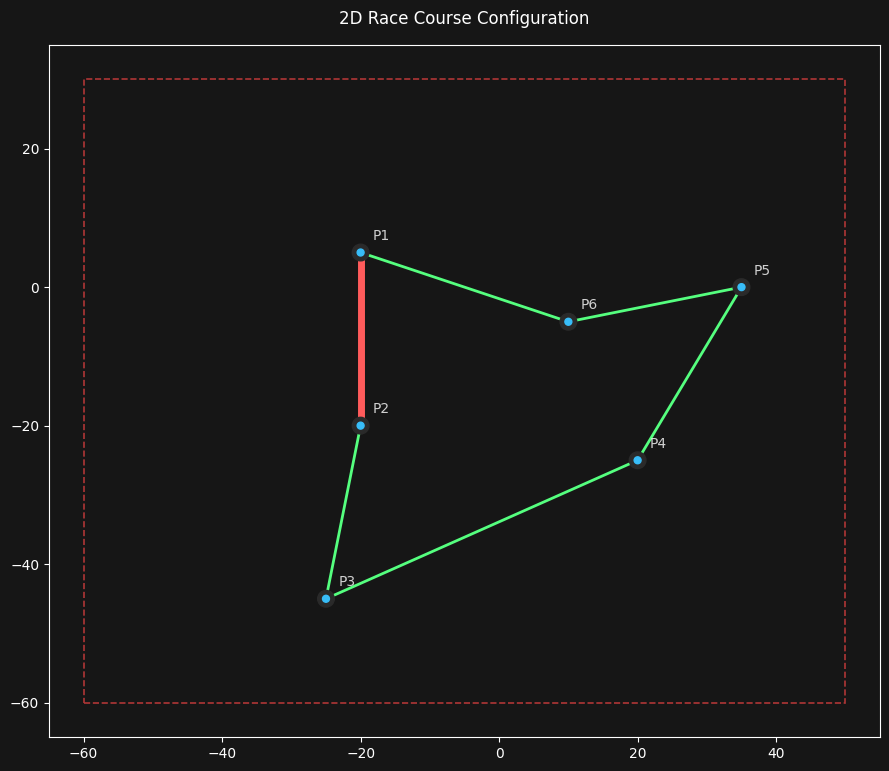

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Updated YAML Pylon Coordinates
pylons = [
    {"x": -20.0, "y":  5.0, "r": 0.25, "name": "P1"},
    {"x": -20.0, "y": -20.0, "r": 0.25, "name": "P2"},
    {"x": -25.0, "y": -45.0, "r": 0.25, "name": "P3"},
    {"x":  20.0, "y": -25.0, "r": 0.25, "name": "P4"},
    {"x":  35.0, "y":   0.0, "r": 0.25, "name": "P5"},
    {"x":  10.0, "y":  -5.0, "r": 0.25, "name": "P6"},
]

# 2. Sequential Gates Loop
gates = [
    {"p1": 0, "p2": 1, "name": "G1 finish"}, # P1 -> P2 (Thick red start/finish line)
    {"p1": 1, "p2": 2, "name": "G2"},
    {"p1": 2, "p2": 3, "name": "G3"},
    {"p1": 3, "p2": 4, "name": "G4"},
    {"p1": 4, "p2": 5, "name": "G5"},
    {"p1": 5, "p2": 0, "name": "G6"},        # Closes the loop
]

# Map limits parsed from bounds_rect
x_min, x_max = -60.0, 50.0
y_min, y_max = -60.0, 30.0

# Plot Configuration
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(9, 8), facecolor='#161616')
ax.set_facecolor('#161616')

# 3. Plot Outer Bounds Rectangle
bounds_box = patches.Rectangle(
    (x_min, y_min), (x_max - x_min), (y_max - y_min), 
    linewidth=1.2, edgecolor='#ef4444', facecolor='none', linestyle='--', alpha=0.7, label='Facility Bounds'
)
ax.add_patch(bounds_box)

# 4. Plot Gate Track Lanes
for gate in gates:
    p1 = pylons[gate["p1"]]
    p2 = pylons[gate["p2"]]
    
    is_finish = "finish" in gate["name"]
    color = "#ff5b5b" if is_finish else "#55ff7f"  # Red for G1, green for other segments
    linewidth = 5.0 if is_finish else 2.0
    
    ax.plot([p1["x"], p2["x"]], [p1["y"], p2["y"]], color=color, linewidth=linewidth, zorder=2)

# 5. Plot Coordinate Pylons
for p in pylons:
    ax.add_patch(patches.Circle((p["x"], p["y"]), 1.2, color='#2a2a2a', zorder=3))
    ax.add_patch(patches.Circle((p["x"], p["y"]), 0.5, color='#38bdf8', zorder=4))
    ax.text(p["x"] + 1.8, p["y"] + 1.8, p["name"], color='#ffffff', fontsize=10, alpha=0.8)

# Framing & Formatting
ax.set_title("2D Race Course Configuration", color='#ffffff', fontsize=12, pad=15)
ax.grid(False)
ax.set_aspect('equal', adjustable='box')

# Adjust viewport padding around the outer boundaries
ax.set_xlim(x_min - 5, x_max + 5)
ax.set_ylim(y_min - 5, y_max + 5)

plt.tight_layout()
plt.show()